# Main Results: Emission-Unit Harmonization

This notebook reproduces the experiments reported in the paper. It evaluates the selected voting ensemble on the augmented random-split dataset, compares it with a majority-class baseline, and tests robustness on rare real-world unit strings.

All reusable implementation code is stored in `src/`; this notebook contains only experiment orchestration, result tables, and visualizations.

## 1. Reproducible setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

from build_and_fit_pipeline import (
    crossvalidate_full_pipeline,
    full_pipeline,
)
from preprocessing import clean_unit, create_features_and_labels, extract_quantity_keyword

data_path = project_root / "data" / "unit_normalization_dict.csv"

## 2. Random-split evaluation and error analysis

c:\Users\up19040\Projekte\LMU\Programmieren mit LMU\unit_harmonization\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


=== MAIN METRICS ===
Accuracy:          95.68%
F1-score weighted: 95.69%
F1-score macro:    96.47%

F1-score micro:    95.68%

=== ADDITIONAL METRICS (weighted) ===
Precision:         95.79%
Recall:            95.68%
F1-score weighted: 95.69%

=== ERROR STATISTICS AND PER-CLASS METRICS ===
            mean_error  count  precision  recall      f1  support
true_label                                                       
t CO2e          0.0725     69     0.9014  0.9275  0.9143       69
kt CO2e         0.0800     50     1.0000  0.9200  0.9583       50
Mt CO2e         0.0541     37     0.8974  0.9459  0.9211       37
kg CO2e         0.0000     25     0.9615  1.0000  0.9804       25
USt CO2e        0.0000     23     1.0000  1.0000  1.0000       23
10 kt CO2e      0.0000     24     0.9600  1.0000  0.9796       24
MM Mt CO2e      0.0000     29     1.0000  1.0000  1.0000       29
Other           0.0442    113     0.9730  0.9558  0.9643      113


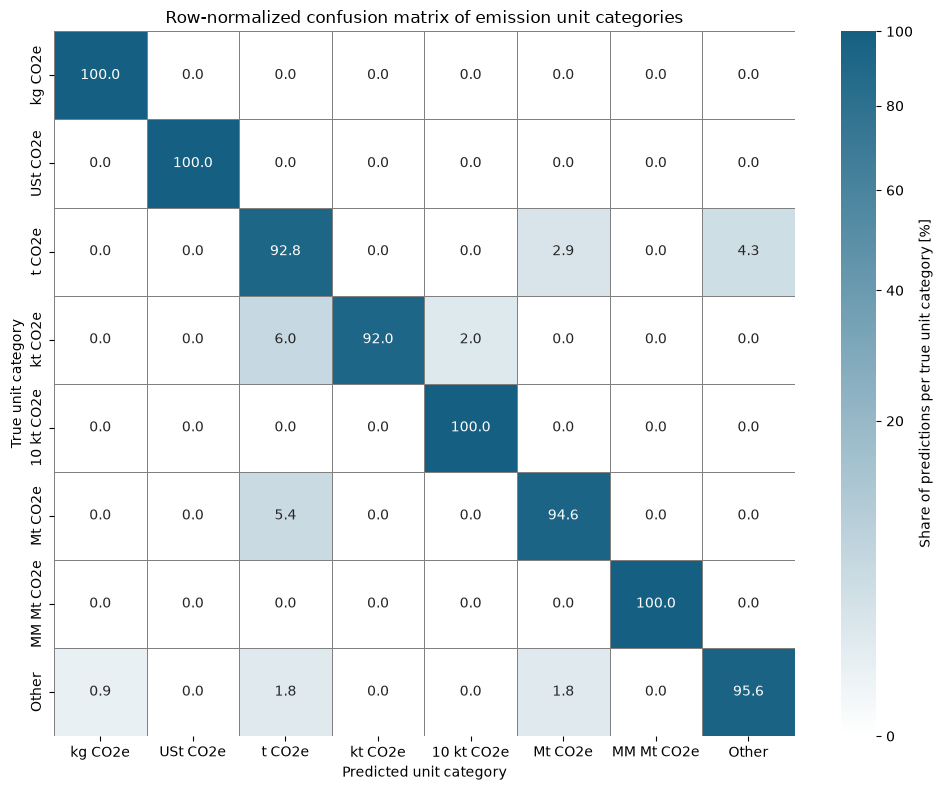


Most frequent confusions:
 Predicted Label  10 kt CO2e  MM Mt CO2e  Mt CO2e  Other  USt CO2e  kg CO2e  \
True Label                                                                   
10 kt CO2e               24           0        0      0         0        0   
MM Mt CO2e                0          29        0      0         0        0   
Mt CO2e                   0           0       35      0         0        0   
Other                     0           0        2    108         0        1   
USt CO2e                  0           0        0      0        23        0   
kg CO2e                   0           0        0      0         0       25   
kt CO2e                   1           0        0      0         0        0   
t CO2e                    0           0        2      3         0        0   

Predicted Label  kt CO2e  t CO2e  
True Label                        
10 kt CO2e             0       0  
MM Mt CO2e             0       0  
Mt CO2e                0       2  
Other           

In [2]:
# Evaluate the selected voting ensemble on the stratified 80/20 random split.
pipeline_results = full_pipeline(
    unit_dict_new=pd.read_csv(data_path),
    ml_model="voting_classifier",
    voting_models=["svm", "mlp", "logistic_regression"],
    random_state=42,
)

In [3]:
# Inspect the unit strings misclassified by the selected ensemble.
with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.max_colwidth", None,
    "display.width", None,
):
    display(pipeline_results["evaluation"]["abweichungen"])

,true_label,predicted_label,orig_index,unit,pred_max_proba,true_class_proba,is_correct
35,t CO2e,Mt CO2e,590,mt CO₂e,NaN,NaN,False
49,kt CO2e,t CO2e,996,th. t CO2 Eq.,NaN,NaN,False
56,kt CO2e,10 kt CO2e,85,1.000 t,NaN,NaN,False
69,kt CO2e,t CO2e,997,Thou. t CO2eq,NaN,NaN,False
89,t CO2e,Other,361,metric tons CO2 equivalent (based on 2016 data),NaN,NaN,False
101,t CO2e,Other,1220,tonnes CO₂e (due to 100% renewable energy use),NaN,NaN,False
120,Other,Mt CO2e,1071,Tn,NaN,NaN,False
154,kt CO2e,t CO2e,217,kt (sum of categories provided),NaN,NaN,False
182,Mt CO2e,t CO2e,572,mn t CO2e (baseline value),NaN,NaN,False
196,Other,t CO2e,130,emissions,NaN,NaN,False


## 3. Ten-fold cross-validation

In [3]:
# Report the 10-fold cross-validation results for the selected ensemble.
cv_results = crossvalidate_full_pipeline(
    unit_dict_new=pd.read_csv(data_path),
    ml_model="voting_classifier",
    voting_models=["svm", "mlp", "logistic_regression"],
    cv_folds=10,
    random_state=42,
)

Mean CV scores (+/- std):
  Accuracy:      95.51% +/- 1.33%
  F1 (weighted): 95.53% +/- 1.32%
  F1 (macro):    96.55% +/- 1.03%
  F1 (micro):    95.51% +/- 1.33%


## 4. Rare-unit robustness evaluation

c:\Users\up19040\Projekte\LMU\Programmieren mit LMU\unit_harmonization\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


=== MAIN METRICS ===
Accuracy:          95.19%
F1-score weighted: 95.19%
F1-score macro:    97.22%

F1-score micro:    95.19%

=== ADDITIONAL METRICS (weighted) ===
Precision:         95.31%
Recall:            95.19%
F1-score weighted: 95.19%

=== ERROR STATISTICS AND PER-CLASS METRICS ===
            mean_error  count  precision  recall      f1  support
true_label                                                       
t CO2e          0.0735     68     0.9545  0.9265  0.9403       68
kt CO2e         0.0408     49     0.9592  0.9592  0.9592       49
Mt CO2e         0.0833     36     1.0000  0.9167  0.9565       36
kg CO2e         0.0526     19     1.0000  0.9474  0.9730       19
USt CO2e        0.0000      4     1.0000  1.0000  1.0000        4
10 kt CO2e      0.0000      1     1.0000  1.0000  1.0000        1
MM Mt CO2e      0.0000      1     1.0000  1.0000  1.0000        1
Other           0.0265    113     0.9244  0.9735  0.9483      113


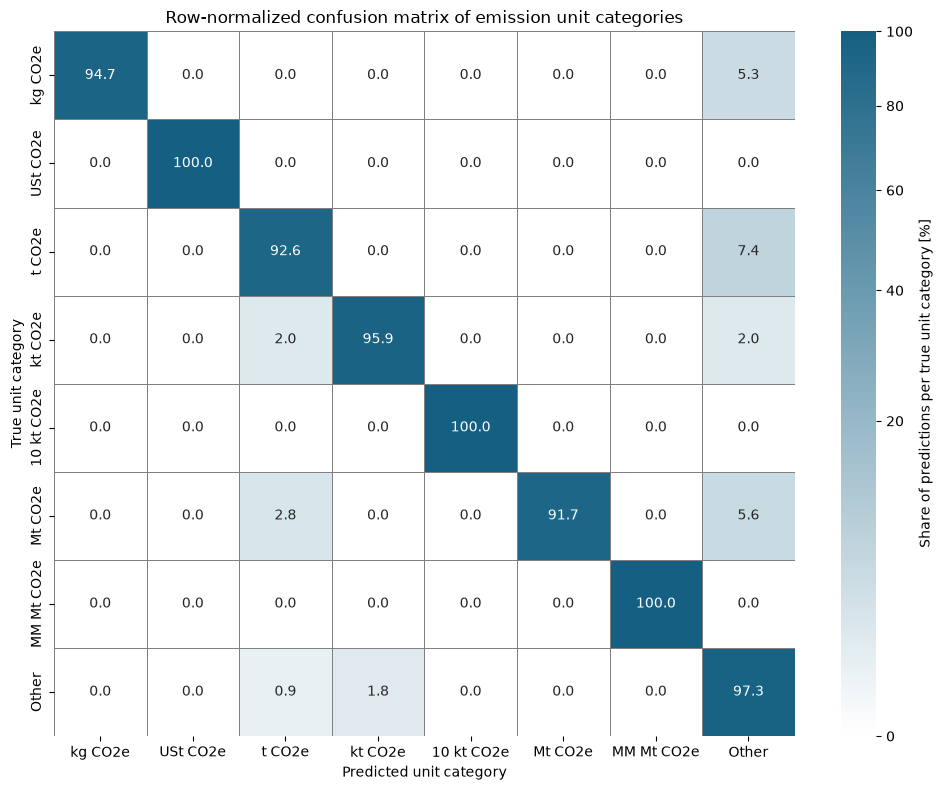


Most frequent confusions:
 Predicted Label  10 kt CO2e  MM Mt CO2e  Mt CO2e  Other  USt CO2e  kg CO2e  \
True Label                                                                   
10 kt CO2e                1           0        0      0         0        0   
MM Mt CO2e                0           1        0      0         0        0   
Mt CO2e                   0           0       33      2         0        0   
Other                     0           0        0    110         0        0   
USt CO2e                  0           0        0      0         4        0   
kg CO2e                   0           0        0      1         0       18   
kt CO2e                   0           0        0      1         0        0   
t CO2e                    0           0        0      5         0        0   

Predicted Label  kt CO2e  t CO2e  
True Label                        
10 kt CO2e             0       0  
MM Mt CO2e             0       0  
Mt CO2e                0       1  
Other           

In [4]:
# Exclude manually observed rare strings from training and evaluate the selected ensemble.
pipeline_results = full_pipeline(
    unit_dict_new=pd.read_csv(data_path),
    split_by_count=True,
    ml_model="voting_classifier",
    voting_models=["svm", "mlp", "logistic_regression"],
    max_count=5,
    include_artificial=False,
    random_state=42,
)

In [6]:
# Inspect errors on the rare-unit test set.
with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.max_colwidth", None,
    "display.width", None,
):
    display(pipeline_results["evaluation"]["abweichungen"])

,true_label,predicted_label,orig_index,unit,pred_max_proba,true_class_proba,is_correct
33,t CO2e,Other,670,t CO2 (remaining emissions),NaN,NaN,False
44,kg CO2e,Other,175,kg CO2eq per year,NaN,NaN,False
133,Mt CO2e,Other,454,million t CO2e (Category 3),NaN,NaN,False
136,Mt CO2e,Other,436,million metric tons of CO2 eq. (Pro forma),NaN,NaN,False
146,kt CO2e,t CO2e,996,th. t CO2 Eq.,NaN,NaN,False
154,Other,kt CO2e,304,kts,NaN,NaN,False
157,t CO2e,Other,922,tCO2e (sum of all Scope 3 categories provided),NaN,NaN,False
188,t CO2e,Other,1220,tonnes CO₂e (due to 100% renewable energy use),NaN,NaN,False
190,Other,kt CO2e,232,kt CO2e (sum of all categories listed for 2022),NaN,NaN,False
201,kt CO2e,Other,53,'000 tCO₂e,NaN,NaN,False


## 5. Majority-class baseline

In [7]:
# Compute the majority-class baseline for both evaluation settings.
unit_dict_new = pd.read_csv(data_path)
X, y_encoded, _ = create_features_and_labels(
    unit_dict_new, extract_quantity_keyword, clean_unit
)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
accuracy_scores = []
f1_weighted_scores = []
f1_macro_scores = []

for train_indices, test_indices in cv.split(X, y_encoded):
    y_train, y_test = y_encoded[train_indices], y_encoded[test_indices]
    values, counts = np.unique(y_train, return_counts=True)
    majority_class = values[np.argmax(counts)]
    y_pred = np.full_like(y_test, fill_value=majority_class)

    accuracy_scores.append(accuracy_score(y_test, y_pred))
    f1_weighted_scores.append(
        f1_score(y_test, y_pred, average="weighted", zero_division=0)
    )
    f1_macro_scores.append(
        f1_score(y_test, y_pred, average="macro", zero_division=0)
    )

print("Ten-fold majority-class baseline:")
print(f"Accuracy:    {np.mean(accuracy_scores):.4f} +/- {np.std(accuracy_scores):.4f}")
print(
    f"F1 weighted: {np.mean(f1_weighted_scores):.4f} +/- "
    f"{np.std(f1_weighted_scores):.4f}"
)
print(f"F1 macro:    {np.mean(f1_macro_scores):.4f} +/- {np.std(f1_macro_scores):.4f}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)
values, counts = np.unique(y_train, return_counts=True)
majority_class = values[np.argmax(counts)]
y_pred = np.full_like(y_test, fill_value=majority_class)

print("\n80/20 random-split majority-class baseline:")
print(f"Accuracy:    {accuracy_score(y_test, y_pred):.4f}")
print(
    f"F1 weighted: {f1_score(y_test, y_pred, average='weighted', zero_division=0):.4f}"
)
print(f"F1 macro:    {f1_score(y_test, y_pred, average='macro', zero_division=0):.4f}")

Ten-fold majority-class baseline:
Accuracy:    0.3067 +/- 0.0026
F1 weighted: 0.1439 +/- 0.0022
F1 macro:    0.0587 +/- 0.0004

80/20 random-split majority-class baseline:
Accuracy:    0.3054
F1 weighted: 0.1429
F1 macro:    0.0585
